# N3 — Ferramentas

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook liga funções Python a um modelo de linguagem. O modelo recebe o nome, a descrição e o esquema de argumentos de cada função, e a resposta dele passa a trazer pedidos de chamada. A execução é da aplicação: o código lê o pedido, roda a função e devolve o resultado ao modelo em uma mensagem de observação.

As seções vão da definição de uma ferramenta isolada até um grafo que alterna chamadas de modelo e execuções de ferramenta até a resposta final. A divisão de trabalho é a mesma em todas: o modelo escolhe a ferramenta e os argumentos, o código executa, e o resultado volta ao modelo como dado de entrada da chamada seguinte.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python: funções, dicionários, anotações de tipo e f-strings;
- serialização de dados em JSON e consultas SQL de leitura;
- declaração de estado com `TypedDict` e construção de grafos com `StateGraph`, `add_node` e `add_edge`;
- roteamento com `add_conditional_edges` e acúmulo de mensagens com o reducer `add_messages`;
- papéis das mensagens de uma conversa: sistema, usuário e assistente.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Definir uma ferramenta com o decorador `@tool` e inspecionar os metadados que ela expõe ao modelo.
2. Separar o pedido de chamada, gravado em `AIMessage.tool_calls`, da execução feita pela aplicação.
3. Devolver o resultado de uma ferramenta em uma `ToolMessage` ligada ao pedido pelo `tool_call_id`.
4. Ligar ferramentas ao modelo com `bind_tools` e completar um turno de ida e volta.
5. Escrever ferramentas que leem um dicionário, um banco SQLite e um cálculo determinístico.
6. Montar em `StateGraph` o laço entre o nó do modelo e o nó de ferramentas, com limite de passos.
7. Trocar o nó e a rota escritos à mão pelos componentes `ToolNode` e `tools_condition`.
8. Executar o mesmo conjunto de ferramentas pelo agente pronto `create_agent`.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Ciclo de chamada de ferramenta.
2. Definição de uma ferramenta.
3. Pedido e observação.
4. Ferramentas ligadas ao modelo.
5. Ferramentas de consulta do curso.
6. Laço de ferramentas em grafo.
7. Componentes prontos.
8. Exercícios de fixação.
9. Resumo da aula.
10. Referências.

## 0.4 Contexto usado nos exemplos

Os exemplos montam um assistente do curso de agentes com LLMs. O curso tem três módulos: `A4`, sobre estado, nós e transições; `A5`, sobre grafos com chamadas de modelo; e `A6`, sobre ferramentas e agentes. Os alunos Julio, Renan e Ana têm progresso registrado nesses módulos.

O assistente responde a três tipos de pedido, e cada um corresponde a uma ferramenta: o cronograma de um módulo, o progresso de um aluno e o número de dias de estudo necessários para uma carga. Nenhum desses dados está no texto do prompt, e o modelo só chega a eles pela chamada de ferramenta.

## 0.5 Preparação do ambiente

O notebook usa o modelo `gpt-oss:120b`, executado na infraestrutura do Ollama e acessado pela API em `https://ollama.com`. Nenhum modelo é baixado na máquina. A seção 0.6 registra também a configuração do Gemini, para o caso de a execução ser feita pela API do Google.

As bibliotecas são `langchain` (decorador `@tool` e `create_agent`), `langgraph` (grafo, reducers e componentes prontos de ferramenta), `langchain-ollama` e `langchain-google-genai` (clientes dos dois provedores) e `python-dotenv` (leitura da chave). O `langchain-google-genai` só é carregado quando a constante `PROVEDOR` da seção 0.6 tem o valor `"gemini"`.

Das seções 4 em diante, a execução depende de tool calling, o mecanismo pelo qual o modelo devolve o nome de uma função declarada no pedido e os argumentos dela. O `gpt-oss:120b` e o `gemini-3.5-flash-lite` têm essa capacidade. Um modelo sem ela responde em texto, `tool_calls` volta como lista vazia e o laço das seções 6 e 7 termina no primeiro passo, sem nenhuma consulta. As seções 2 e 3 rodam sem chamar modelo.

O acesso ao modelo hospedado exige uma chave de API. Os passos para obtê-la:

1. Criar uma conta em [ollama.com](https://ollama.com) e entrar nela.
2. Abrir [ollama.com/settings/keys](https://ollama.com/settings/keys) e gerar uma chave nova.
3. Copiar o valor exibido, que aparece uma única vez.
4. Guardar o valor na variável de ambiente `OLLAMA_API_KEY`.

Há três formas de cumprir o passo 4. Em uma máquina local, escreva a linha `OLLAMA_API_KEY=...` em um arquivo `.env` ao lado do notebook, que já está no `.gitignore`, e deixe o `load_dotenv()` da seção 0.6 carregá-la. A segunda forma é exportar a variável no ambiente antes de abrir o notebook. A terceira é a célula comentada abaixo, para o Google Colab. Não escreva a chave no código versionado.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langchain langgraph langchain-ollama langchain-google-genai python-dotenv

A célula a seguir cobre o caso do Google Colab, onde não há arquivo `.env`. Descomente as três linhas, cole a chave entre as aspas e execute a célula. Torne a comentá-las antes de salvar o notebook, para que a chave não seja gravada no arquivo.

In [2]:
# # Descomente no Google Colab, onde não há arquivo .env.
# import os
# os.environ["OLLAMA_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

Agora importamos os elementos que serão usados ao longo da aula.

In [3]:
import json
import math
import os
import sqlite3

from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from typing import Annotated, Literal, TypedDict

Glossário dos imports:

- `json`, `math` e `sqlite3`: serialização do retorno das ferramentas, arredondamento do plano de estudo e banco de progresso da seção 5;
- `os` e `load_dotenv`: leitura das chaves de API a partir do ambiente ou do arquivo `.env`;
- `create_agent`: monta o grafo do agente com ferramentas já ligado, usado na seção 7;
- `tool`: decorador que converte uma função Python em ferramenta com nome, descrição e esquema;
- `AIMessage`, `HumanMessage`, `SystemMessage` e `ToolMessage`: a resposta do modelo, o pedido do aluno, a instrução fixa e o resultado de uma ferramenta;
- `AnyMessage`: tipo comum às mensagens, usado na anotação do estado;
- `ChatOllama` e `ChatGoogleGenerativeAI`: clientes dos dois provedores configurados na seção 0.6;
- `StateGraph`, `START` e `END`: construtor do grafo e os nós virtuais de entrada e saída;
- `add_messages`: reducer que concatena mensagens no estado em vez de substituí-las;
- `ToolNode` e `tools_condition`: nó de execução de ferramentas e função de rota prontos, usados na seção 7;
- `TypedDict`, `Annotated` e `Literal`: campos do estado, associação do reducer e conjunto fechado de valores.

As duas funções auxiliares abaixo são usadas nas células de exemplo. A primeira exibe o desenho de um grafo compilado; a segunda imprime uma conversa mensagem a mensagem, separando o texto dos pedidos de chamada.

In [4]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display


def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))


def mostrar_conversa(mensagens: list[AnyMessage]) -> None:
    """Imprime cada mensagem com o tipo, os pedidos de chamada e o conteúdo."""
    for indice, mensagem in enumerate(mensagens):
        print(f"[{indice}] {type(mensagem).__name__}")

        for chamada in getattr(mensagem, "tool_calls", []):
            print(f"    pedido: {chamada['name']}({chamada['args']})")

        if mensagem.text:
            rotulo = "resultado" if isinstance(mensagem, ToolMessage) else "texto"
            print(f"    {rotulo}: {mensagem.text[:300]}")

        print("-" * 60)

## 0.6 Escolhendo um provedor de LLM

O notebook instancia o modelo por uma função única, `criar_modelo`, e as seções seguintes chamam o objeto devolvido por ela. A constante `PROVEDOR` seleciona qual cliente é construído.

Os dois provedores diferem nos pontos da tabela abaixo, e `criar_modelo` concentra os que afetam a construção do cliente:

| Ponto | Ollama | Gemini |
|---|---|---|
| Classe | `ChatOllama` | `ChatGoogleGenerativeAI` |
| Conexão | `base_url` em `https://ollama.com` e cabeçalho `Authorization` entregue por `client_kwargs` | chave entregue em `api_key` |
| Limite de tokens da resposta | `num_predict` | `max_output_tokens` |
| Amostragem | `temperature` | fixa; a família Gemini 3.x não aceita `temperature`, `top_p` nem `top_k` |
| Raciocínio | `reasoning` | `thinking_level`, com os valores `minimal`, `low`, `medium` e `high` |
| Campo `content` da resposta | uma string | uma lista de blocos |

A interface de tool calling é a mesma nos dois: `bind_tools` recebe a lista de ferramentas, e o pedido de chamada chega em `tool_calls`, com o mesmo formato de dicionário. As células das seções 4 a 7 não mudam com a troca de `PROVEDOR`.

As saídas gravadas neste arquivo vêm do Ollama. Para executar pelo Gemini, gere uma chave em [aistudio.google.com/apikey](https://aistudio.google.com/apikey), guarde-a na variável `GOOGLE_API_KEY` e troque o valor de `PROVEDOR`.

O parâmetro `reasoning=False` retira o texto de raciocínio do `gpt-oss` do campo da resposta. Os tokens de raciocínio continuam sendo gerados e continuam contando no orçamento de `num_predict`. Quando o orçamento acaba antes da resposta visível, a chamada volta com `done_reason` igual a `length` e sem texto. O valor 1200 de `LIMITE_RESPOSTA` deixa margem para as duas partes, e o laço da seção 6 faz mais de uma chamada por pergunta.

In [5]:
load_dotenv()

PROVEDOR = "ollama"  # troque para "gemini" depois de definir GOOGLE_API_KEY

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 1200  # tokens gerados por chamada


def criar_modelo(provedor: str = PROVEDOR):
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if provedor == "ollama":
        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if provedor == "gemini":
        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env "
                "ou no ambiente do sistema."
            )

        # A família Gemini 3.x não aceita temperature, top_p nem top_k.
        # O nível de raciocínio ocupa o lugar do reasoning do Ollama.
        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {provedor}. Use 'ollama' ou 'gemini'.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

ollama | ChatOllama


---

# 1. Ciclo de chamada de ferramenta

Uma ferramenta é uma função Python declarada ao modelo por três metadados: o nome, a descrição e o esquema de argumentos. A declaração vai junto com as mensagens no pedido. A resposta do modelo passa a ter duas formas possíveis: um texto para o usuário, ou uma lista de pedidos de chamada, cada um com o nome de uma das funções declaradas e os argumentos preenchidos.

O modelo não roda a função. O pedido é um dado dentro da resposta, e quem lê esse dado, localiza a função e a executa é o código da aplicação. O resultado volta ao modelo como uma mensagem nova, e a chamada seguinte tem esse resultado no histórico.

```text
pergunta do aluno
  ↓
modelo com ferramentas ligadas
  ↓
AIMessage com tool_calls        ← pedido de chamada
  ↓
aplicação executa a função Python
  ↓
ToolMessage com o resultado     ← observação
  ↓
modelo lê a observação
  ↓
AIMessage sem tool_calls        ← resposta final
```

O ciclo se repete enquanto a resposta trouxer pedidos de chamada. Três mecanismos aparecem em cada volta, e as seções seguintes tratam de um por vez: a declaração da ferramenta (seção 2), o par pedido e observação (seções 3 e 4) e o controle da repetição (seções 6 e 7).

---

# 2. Definição de uma ferramenta

O decorador `@tool` converte uma função Python em ferramenta. Os três metadados vêm do próprio código: o nome da função vira o nome da ferramenta, a docstring vira a descrição, e as anotações de tipo dos parâmetros viram o esquema de argumentos em JSON Schema.

O argumento `parse_docstring=True` separa as duas partes da docstring escrita no formato do Google. O resumo da primeira linha vira a descrição da ferramenta, e cada entrada do bloco `Args:` vira a descrição do parâmetro correspondente dentro do esquema. Sem esse argumento, a docstring inteira, com o bloco `Args:` no meio, vira a descrição, e o esquema fica com o nome e o tipo de cada parâmetro, sem texto que diga o que cada um significa.

A ferramenta abaixo converte uma quantidade de aulas e a duração de cada uma em carga horária total. O retorno é uma string JSON, formato que o modelo lê como texto e a aplicação lê como dado estruturado.

In [6]:
@tool(parse_docstring=True)
def calcular_carga_total(quantidade_aulas: int, minutos_por_aula: int) -> str:
    """Calcula a carga horária total de um conjunto de aulas do curso.

    Args:
        quantidade_aulas: número de aulas do conjunto.
        minutos_por_aula: duração de cada aula em minutos.
    """
    total_minutos = quantidade_aulas * minutos_por_aula

    return json.dumps(
        {
            "quantidade_aulas": quantidade_aulas,
            "minutos_por_aula": minutos_por_aula,
            "total_minutos": total_minutos,
            "total_formatado": f"{total_minutos // 60}h{total_minutos % 60:02d}min",
        },
        ensure_ascii=False,
    )


print("nome:", calcular_carga_total.name)
print("descrição:", calcular_carga_total.description)
print("argumentos:", calcular_carga_total.args)

nome: calcular_carga_total
descrição: Calcula a carga horária total de um conjunto de aulas do curso.
argumentos: {'quantidade_aulas': {'description': 'número de aulas do conjunto.', 'title': 'Quantidade Aulas', 'type': 'integer'}, 'minutos_por_aula': {'description': 'duração de cada aula em minutos.', 'title': 'Minutos Por Aula', 'type': 'integer'}}


## 2.1 Metadados expostos ao modelo

O objeto devolvido pelo decorador expõe três atributos, e o modelo recebe os três:

1. `name`: o identificador usado no pedido de chamada, igual ao nome da função;
2. `description`: o resumo da docstring, que informa em que situação a função se aplica;
3. `args`: o esquema com o nome, o tipo e a descrição de cada parâmetro, esta última extraída do bloco `Args:`.

O corpo da função não é enviado ao modelo. A escolha da ferramenta é feita sobre esses três campos, e uma descrição que não diz em que caso a função se aplica deixa o modelo sem o critério de seleção.

## 2.2 Execução sem modelo

A ferramenta continua sendo uma função Python. O método `invoke` recebe os argumentos em um dicionário, roda o corpo e devolve o retorno, sem que nenhum modelo participe.

In [7]:
resultado = calcular_carga_total.invoke({"quantidade_aulas": 6, "minutos_por_aula": 50})

print(resultado)
print(type(resultado))

{"quantidade_aulas": 6, "minutos_por_aula": 50, "total_minutos": 300, "total_formatado": "5h00min"}
<class 'str'>


---

# 3. Pedido e observação

Um pedido de chamada é um dicionário com quatro chaves: `name`, `args`, `id` e `type`. Ele chega dentro do campo `tool_calls` de uma `AIMessage`. A célula abaixo monta esse dicionário à mão, no mesmo formato que o modelo produz; nenhuma chamada ao provedor acontece nesta seção.

Fluxo:

```text
AIMessage(tool_calls=[{name, args, id}])  →  execução  →  ToolMessage(content, tool_call_id)
```

In [8]:
pedido = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "calcular_carga_total",
            "args": {"quantidade_aulas": 6, "minutos_por_aula": 50},
            "id": "chamada_001",
            "type": "tool_call",
        }
    ],
)

print("texto da mensagem:", repr(pedido.text))
print("pedidos de chamada:", pedido.tool_calls)

texto da mensagem: ''
pedidos de chamada: [{'name': 'calcular_carga_total', 'args': {'quantidade_aulas': 6, 'minutos_por_aula': 50}, 'id': 'chamada_001', 'type': 'tool_call'}]


## 3.1 Campos do pedido

O campo `content` está vazio, e a informação da mensagem está em `tool_calls`. Cada item traz o nome da função escolhida, os argumentos já preenchidos e um identificador gerado pelo provedor. O identificador liga o resultado ao pedido quando a resposta contém mais de uma chamada.

Nada foi executado até aqui. A célula abaixo faz o trabalho da aplicação: monta o mapa de ferramentas por nome, localiza a função pedida, executa com os argumentos recebidos e embrulha o retorno em uma `ToolMessage`.

In [9]:
ferramentas = [calcular_carga_total]
ferramentas_por_nome = {ferramenta.name: ferramenta for ferramenta in ferramentas}

chamada = pedido.tool_calls[0]
observacao = ferramentas_por_nome[chamada["name"]].invoke(chamada["args"])

resposta_ferramenta = ToolMessage(
    content=observacao,
    tool_call_id=chamada["id"],
)

conversa = [
    HumanMessage("Qual é a carga total de 6 aulas de 50 minutos?"),
    pedido,
    resposta_ferramenta,
]

mostrar_conversa(conversa)

[0] HumanMessage
    texto: Qual é a carga total de 6 aulas de 50 minutos?
------------------------------------------------------------
[1] AIMessage
    pedido: calcular_carga_total({'quantidade_aulas': 6, 'minutos_por_aula': 50})
------------------------------------------------------------
[2] ToolMessage
    resultado: {"quantidade_aulas": 6, "minutos_por_aula": 50, "total_minutos": 300, "total_formatado": "5h00min"}
------------------------------------------------------------


## 3.2 Leitura da execução

1. `ferramentas_por_nome` associa o nome declarado ao objeto da ferramenta.
2. `chamada["name"]` localiza a ferramenta, e `chamada["args"]` entra direto em `invoke`.
3. O retorno vira o `content` da `ToolMessage`.
4. `tool_call_id` recebe o `id` do pedido.

A conversa impressa tem três mensagens e é o histórico que o modelo receberia na chamada seguinte. A `ToolMessage` sem um `tool_call_id` correspondente a um pedido anterior é recusada pelos provedores, porque a associação entre pedido e resultado é feita por esse campo, e não pela ordem das mensagens.

---

# 4. Ferramentas ligadas ao modelo

O método `bind_tools` devolve uma cópia do modelo com a lista de ferramentas anexada aos pedidos. A execução continua fora do modelo: `bind_tools` altera o que é enviado ao provedor e o que volta na resposta, e não roda nenhuma função. A célula abaixo liga a ferramenta da seção 2 e envia uma pergunta cujos números não aparecem em nenhuma das mensagens anteriores.

In [10]:
modelo_com_ferramentas = modelo.bind_tools(ferramentas)

pergunta = HumanMessage(
    "No curso de agentes com LLMs, qual é a carga total de 4 aulas de 45 minutos?"
)

resposta = modelo_com_ferramentas.invoke([pergunta])

print("texto da resposta:", repr(resposta.text))
print("pedidos de chamada:", resposta.tool_calls)

texto da resposta: ''
pedidos de chamada: [{'name': 'calcular_carga_total', 'args': {'minutos_por_aula': 45, 'quantidade_aulas': 4}, 'id': '426435f9-6e2f-4656-8a91-84f3440cf504', 'type': 'tool_call'}]


## 4.1 Leitura da execução

O modelo devolveu uma `AIMessage` com o campo de texto vazio e um item em `tool_calls`. O nome corresponde à ferramenta ligada, e os argumentos foram extraídos do enunciado da pergunta: `quantidade_aulas` recebeu 4 e `minutos_por_aula` recebeu 45.

A resposta não tem o resultado do cálculo, porque a função não rodou. O `id` desta chamada foi gerado pelo provedor, e a `ToolMessage` da subseção seguinte repete esse valor.

## 4.2 Retorno da observação

O turno se completa em três passos: executar cada pedido, acrescentar as `ToolMessage` ao histórico e chamar o modelo de novo com o histórico inteiro. A segunda chamada recebe o resultado do cálculo e produz o texto para o aluno.

In [11]:
observacoes = [
    ToolMessage(
        content=ferramentas_por_nome[chamada["name"]].invoke(chamada["args"]),
        tool_call_id=chamada["id"],
    )
    for chamada in resposta.tool_calls
]

historico = [pergunta, resposta, *observacoes]
resposta_final = modelo_com_ferramentas.invoke(historico)

mostrar_conversa(observacoes)
print(resposta_final.text)

[0] ToolMessage
    resultado: {"quantidade_aulas": 4, "minutos_por_aula": 45, "total_minutos": 180, "total_formatado": "3h00min"}
------------------------------------------------------------
A carga horária total das 4 aulas, cada uma com 45 min, é **180 minutos**, ou seja, **3 horas**.


## 4.3 Papel da descrição

A pergunta desta seção não nomeia a ferramenta. O modelo comparou o texto da pergunta com a descrição registrada em `description`, e tirou do enunciado os dois valores que o esquema de argumentos declara.

Duas consequências aparecem no restante do notebook. A primeira é que a docstring de uma ferramenta é lida pelo modelo a cada chamada e faz parte do custo em tokens de todo pedido. A segunda é que o número de chamadas por resposta não é fixo: a resposta pode trazer nenhum pedido, um pedido, ou vários pedidos independentes, e o código que executa precisa iterar sobre a lista, como faz a compreensão de lista da subseção 4.2.

---

# 5. Ferramentas de consulta do curso

As ferramentas desta seção dão ao assistente acesso a três fontes de dados: um dicionário com o cronograma dos módulos, um banco SQLite com o progresso dos alunos e um cálculo de plano de estudo. As três devolvem string JSON e seguem a mesma convenção de erro: um objeto com a chave `erro` e a lista de valores aceitos, em vez de uma exceção.

## 5.1 Cronograma dos módulos

A primeira ferramenta lê o cronograma de um módulo pelo código. O dicionário ocupa aqui o lugar que uma API de sistema acadêmico ocuparia em um sistema em produção, e a assinatura da ferramenta continua a mesma nos dois casos.

In [12]:
CRONOGRAMA = {
    "A4": {
        "titulo": "Estado, nós e transições",
        "duracao_min": 90,
        "pre_requisitos": [],
    },
    "A5": {
        "titulo": "Grafos com chamadas de modelo",
        "duracao_min": 120,
        "pre_requisitos": ["A4"],
    },
    "A6": {
        "titulo": "Ferramentas e agentes",
        "duracao_min": 150,
        "pre_requisitos": ["A4", "A5"],
    },
}


@tool(parse_docstring=True)
def consultar_cronograma(codigo_modulo: str) -> str:
    """Consulta título, duração em minutos e pré-requisitos de um módulo do curso.

    Args:
        codigo_modulo: código do módulo, como A4, A5 ou A6.
    """
    codigo = codigo_modulo.strip().upper()
    modulo = CRONOGRAMA.get(codigo)

    if modulo is None:
        return json.dumps(
            {"erro": "modulo_desconhecido", "modulos_disponiveis": list(CRONOGRAMA)},
            ensure_ascii=False,
        )

    return json.dumps({"codigo": codigo, **modulo}, ensure_ascii=False)


print(consultar_cronograma.invoke({"codigo_modulo": "a6"}))
print(consultar_cronograma.invoke({"codigo_modulo": "A9"}))

{"codigo": "A6", "titulo": "Ferramentas e agentes", "duracao_min": 150, "pre_requisitos": ["A4", "A5"]}
{"erro": "modulo_desconhecido", "modulos_disponiveis": ["A4", "A5", "A6"]}


## 5.2 Progresso em banco de dados

A segunda ferramenta consulta um banco SQLite criado em memória, com duas tabelas: `alunos` e `progresso`. A célula abaixo cria o esquema e insere as linhas dos três alunos do contexto.

O argumento `check_same_thread=False` libera a consulta a essa conexão de dentro do grafo. O LangGraph executa os nós em threads de um pool, e a verificação padrão do `sqlite3` recusa uma conexão usada fora da thread que a criou.

In [13]:
# O nó de ferramentas roda em outra thread, e a conexão precisa aceitar isso.
conexao = sqlite3.connect(":memory:", check_same_thread=False)

conexao.execute("CREATE TABLE alunos (id INTEGER PRIMARY KEY, nome TEXT NOT NULL)")
conexao.execute(
    """
    CREATE TABLE progresso (
        aluno_id INTEGER NOT NULL,
        modulo TEXT NOT NULL,
        status TEXT NOT NULL,
        percentual INTEGER NOT NULL
    )
    """
)

conexao.executemany(
    "INSERT INTO alunos (id, nome) VALUES (?, ?)",
    [(1, "Julio"), (2, "Renan"), (3, "Ana")],
)

conexao.executemany(
    "INSERT INTO progresso (aluno_id, modulo, status, percentual) VALUES (?, ?, ?, ?)",
    [
        (1, "A4", "concluido", 100),
        (1, "A5", "concluido", 100),
        (1, "A6", "nao_iniciado", 0),
        (2, "A4", "concluido", 100),
        (2, "A5", "em_andamento", 50),
        (2, "A6", "nao_iniciado", 0),
        (3, "A4", "em_andamento", 70),
        (3, "A5", "nao_iniciado", 0),
        (3, "A6", "nao_iniciado", 0),
    ],
)

conexao.commit()

print(conexao.execute("SELECT count(*) FROM progresso").fetchone())

(9,)


A ferramenta abaixo recebe o nome do aluno, faz a junção das duas tabelas e devolve a lista de módulos com status e percentual. A consulta usa parâmetro posicional, e o valor recebido do modelo não é concatenado ao texto do SQL. Um nome sem linhas na junção cai na convenção de erro, com a lista de alunos registrados no lugar do resultado.

In [14]:
@tool(parse_docstring=True)
def consultar_progresso(nome_aluno: str) -> str:
    """Consulta o status e o percentual de um aluno em cada módulo do curso.

    Args:
        nome_aluno: primeiro nome do aluno, como Julio, Renan ou Ana.
    """
    linhas = conexao.execute(
        """
        SELECT a.nome, p.modulo, p.status, p.percentual
        FROM alunos a
        JOIN progresso p ON p.aluno_id = a.id
        WHERE lower(a.nome) = lower(?)
        ORDER BY p.modulo
        """,
        (nome_aluno.strip(),),
    ).fetchall()

    if not linhas:
        registrados = [nome for (nome,) in conexao.execute("SELECT nome FROM alunos")]

        return json.dumps(
            {
                "erro": "aluno_desconhecido",
                "aluno_solicitado": nome_aluno,
                "alunos_disponiveis": registrados,
            },
            ensure_ascii=False,
        )

    return json.dumps(
        {
            "aluno": linhas[0][0],
            "modulos": [
                {"modulo": modulo, "status": status, "percentual": percentual}
                for _, modulo, status, percentual in linhas
            ],
        },
        ensure_ascii=False,
    )


print(consultar_progresso.invoke({"nome_aluno": "renan"}))
print(consultar_progresso.invoke({"nome_aluno": "Pedro"}))

{"aluno": "Renan", "modulos": [{"modulo": "A4", "status": "concluido", "percentual": 100}, {"modulo": "A5", "status": "em_andamento", "percentual": 50}, {"modulo": "A6", "status": "nao_iniciado", "percentual": 0}]}
{"erro": "aluno_desconhecido", "aluno_solicitado": "Pedro", "alunos_disponiveis": ["Julio", "Renan", "Ana"]}


## 5.3 Plano de estudo

A terceira ferramenta converte a carga de um módulo em número de dias, a partir do tempo disponível por dia. O resultado é determinístico e não depende do modelo, que costuma errar aritmética feita de cabeça.

In [15]:
@tool(parse_docstring=True)
def calcular_plano_estudo(carga_minutos: int, minutos_por_dia: int) -> str:
    """Calcula em quantos dias uma carga de estudo cabe na disponibilidade diária.

    Args:
        carga_minutos: duração total do módulo em minutos.
        minutos_por_dia: minutos disponíveis por dia de estudo.
    """
    if carga_minutos <= 0 or minutos_por_dia <= 0:
        return json.dumps(
            {"erro": "valor_invalido", "mensagem": "Os dois valores devem ser positivos."},
            ensure_ascii=False,
        )

    dias = math.ceil(carga_minutos / minutos_por_dia)
    ultima_sessao = carga_minutos - (dias - 1) * minutos_por_dia

    return json.dumps(
        {
            "dias": dias,
            "minutos_por_dia": minutos_por_dia,
            "ultima_sessao_min": ultima_sessao,
        },
        ensure_ascii=False,
    )


print(calcular_plano_estudo.invoke({"carga_minutos": 150, "minutos_por_dia": 45}))
print(calcular_plano_estudo.invoke({"carga_minutos": 0, "minutos_por_dia": 45}))

{"dias": 4, "minutos_por_dia": 45, "ultima_sessao_min": 15}
{"erro": "valor_invalido", "mensagem": "Os dois valores devem ser positivos."}


## 5.4 Registro das ferramentas

As três ferramentas entram em uma lista, e a lista é o argumento de `bind_tools` e dos componentes das seções 6 e 7. O nó de execução da seção 6 monta o mapa por nome a partir dessa lista a cada chamada, e uma ferramenta acrescentada à lista passa a ser encontrada sem outra alteração no nó.

In [16]:
FERRAMENTAS_CURSO = [consultar_cronograma, consultar_progresso, calcular_plano_estudo]

for ferramenta in FERRAMENTAS_CURSO:
    print(ferramenta.name)
    print("   ", ferramenta.description)
    print("   ", list(ferramenta.args))

consultar_cronograma
    Consulta título, duração em minutos e pré-requisitos de um módulo do curso.
    ['codigo_modulo']
consultar_progresso
    Consulta o status e o percentual de um aluno em cada módulo do curso.
    ['nome_aluno']
calcular_plano_estudo
    Calcula em quantos dias uma carga de estudo cabe na disponibilidade diária.
    ['carga_minutos', 'minutos_por_dia']


## 5.5 Discussão

As três ferramentas têm a mesma interface e fontes de dado diferentes:

| Ferramenta | Fonte | Papel na resposta |
|---|---|---|
| `consultar_cronograma` | dicionário em memória, no lugar de uma API | duração e pré-requisitos de um módulo |
| `consultar_progresso` | banco SQLite com duas tabelas | status do aluno em cada módulo |
| `calcular_plano_estudo` | cálculo em Python | conversão de carga em dias |

A convenção de erro é a mesma nas três: um código em `erro` e a informação que permite refazer o pedido, como a lista de módulos aceitos. O erro chega ao modelo pelo mesmo caminho do resultado, em uma `ToolMessage`, e vira entrada da chamada seguinte. Uma exceção levantada dentro da ferramenta interrompe o grafo e não chega ao modelo. A subseção 6.5 executa esse caso dentro do laço.

O modelo recebe o texto do JSON, e não um objeto Python. Os nomes das chaves fazem parte do texto lido e do custo em tokens de cada observação.

---

# 6. Laço de ferramentas em grafo

O turno de ida e volta da seção 4 foi escrito à mão e cobre um pedido. Uma pergunta que depende de duas consultas encadeadas, como a duração do A6 seguida do cálculo de dias, exige repetir o ciclo até a resposta vir sem pedidos. Essa repetição é o grafo desta seção: um nó chama o modelo, outro executa as ferramentas, e uma aresta condicional escolhe entre voltar ao modelo e terminar.

O estado tem dois campos: `messages`, com o reducer `add_messages`, e `passos`, que conta as chamadas de modelo. O campo `passos` é escrito pelo nó do modelo e lido pela rota, e a entrada do grafo o inicia em zero.

Fluxo:

```text
START → chamar_modelo → decidir_proximo_no
                            ├── com pedidos e abaixo do limite → executar_ferramentas → chamar_modelo
                            └── caso contrário                 → END
```

In [17]:
PROMPT_ASSISTENTE = """Atue como assistente do curso de agentes com LLMs.
O curso tem os módulos A4, A5 e A6.
Consulte o cronograma antes de afirmar duração ou pré-requisito de um módulo.
Consulte o progresso antes de afirmar o que um aluno concluiu.
Use a ferramenta de plano para converter carga em dias.
Responda em português, em no máximo quatro frases."""

LIMITE_PASSOS = 4

modelo_assistente = modelo.bind_tools(FERRAMENTAS_CURSO)


class EstadoFerramentas(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    passos: int


def chamar_modelo(state: EstadoFerramentas) -> dict:
    """Chama o modelo com o prompt de sistema e o histórico, e conta o passo."""
    resposta = modelo_assistente.invoke(
        [SystemMessage(PROMPT_ASSISTENTE), *state["messages"]]
    )

    return {"messages": [resposta], "passos": state["passos"] + 1}


def executar_ferramentas(state: EstadoFerramentas) -> dict:
    """Executa os pedidos da última mensagem e devolve uma ToolMessage por pedido."""
    por_nome = {ferramenta.name: ferramenta for ferramenta in FERRAMENTAS_CURSO}

    observacoes = [
        ToolMessage(
            content=por_nome[chamada["name"]].invoke(chamada["args"]),
            tool_call_id=chamada["id"],
        )
        for chamada in state["messages"][-1].tool_calls
    ]

    return {"messages": observacoes}

## 6.1 Rota do laço

A função de rota lê a última mensagem do estado e devolve um dos dois destinos do mapa. O campo `passos` entra na condição para encerrar uma sequência de pedidos que não chega a uma resposta.

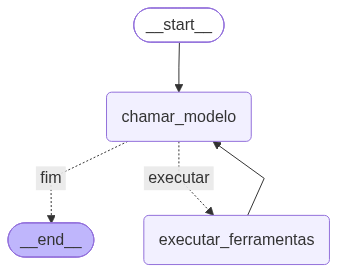

In [18]:
def decidir_proximo_no(state: EstadoFerramentas) -> Literal["executar", "fim"]:
    """Continua enquanto houver pedido de chamada e o limite de passos não for atingido."""
    if state["messages"][-1].tool_calls and state["passos"] < LIMITE_PASSOS:
        return "executar"

    return "fim"


builder = StateGraph(EstadoFerramentas)

builder.add_node("chamar_modelo", chamar_modelo)
builder.add_node("executar_ferramentas", executar_ferramentas)

builder.add_edge(START, "chamar_modelo")

builder.add_conditional_edges(
    "chamar_modelo",
    decidir_proximo_no,
    {"executar": "executar_ferramentas", "fim": END},
)

builder.add_edge("executar_ferramentas", "chamar_modelo")

graph = builder.compile()

display_graph(graph)

## 6.2 Execução do agente

A pergunta abaixo depende de duas ferramentas em sequência: a duração do A6 sai do cronograma e entra como argumento do plano de estudo. A execução é acompanhada com `stream_mode="updates"`, que emite um evento por nó executado.

In [19]:
entrada = {
    "messages": [
        HumanMessage(
            "Sou o aluno Renan. Quanto tempo dura o módulo A6 e em quantos dias "
            "eu o concluo estudando 45 minutos por dia?"
        )
    ],
    "passos": 0,
}

for evento in graph.stream(entrada, stream_mode="updates"):
    for no, atualizacao in evento.items():
        for mensagem in atualizacao["messages"]:
            pedidos = [chamada["name"] for chamada in getattr(mensagem, "tool_calls", [])]
            print(f"{no:22} | {type(mensagem).__name__:13} | {pedidos or mensagem.text[:60]}")

chamar_modelo          | AIMessage     | ['consultar_cronograma']
executar_ferramentas   | ToolMessage   | {"codigo": "A6", "titulo": "Ferramentas e agentes", "duracao
chamar_modelo          | AIMessage     | ['calcular_plano_estudo']
executar_ferramentas   | ToolMessage   | {"dias": 4, "minutos_por_dia": 45, "ultima_sessao_min": 15}
chamar_modelo          | AIMessage     | O módulo A6 tem duração de 150 min. Estudando 45 min por dia


## 6.3 Leitura da execução

A execução gravada acima percorreu esta sequência:

1. `chamar_modelo` recebe a pergunta e devolve uma `AIMessage` com o pedido de `consultar_cronograma`.
2. `decidir_proximo_no` encontra o pedido e devolve `executar`.
3. `executar_ferramentas` roda a consulta e acrescenta a `ToolMessage` com a duração de 150 minutos.
4. `chamar_modelo` roda de novo, agora com a duração no histórico, e pede `calcular_plano_estudo`.
5. O ciclo se repete, e a terceira chamada volta sem pedidos, o que leva a rota a `fim`.

O segundo pedido usa um valor que estava no resultado do primeiro. Esse encadeamento separa o laço do turno único da seção 4: o histórico cresce a cada volta, e cada chamada de modelo é feita sobre tudo o que já foi observado.

A contagem em `passos` limita as chamadas de modelo, e não as ferramentas por chamada. Uma resposta com três pedidos executa três funções e consome um passo.

A sequência acima não se repete a cada execução. O número de pedidos por resposta e o agrupamento deles dependem do provedor, do modelo e da amostragem, e a mesma pergunta pode produzir percursos diferentes em corridas sucessivas. Quando duas consultas são independentes, o modelo pode trazer as duas na mesma `AIMessage`, e o nó devolve uma `ToolMessage` por pedido em uma volta só. O encadeamento do passo 4 não muda com isso, porque o argumento do plano de estudo depende do resultado da consulta anterior.

## 6.4 Estado final

O grafo devolve o estado com o histórico inteiro. A última mensagem é a resposta ao aluno, e as intermediárias registram o percurso: cada pedido e cada observação que o produziu. A pergunta abaixo se resolve com uma consulta, e o histórico fica com o percurso mais curto do laço.

In [20]:
resultado = graph.invoke(
    {
        "messages": [HumanMessage("O aluno Julio já concluiu o módulo A5?")],
        "passos": 0,
    }
)

print("passos:", resultado["passos"], "| mensagens:", len(resultado["messages"]))
print("-" * 60)
mostrar_conversa(resultado["messages"])

passos: 2 | mensagens: 4
------------------------------------------------------------
[0] HumanMessage
    texto: O aluno Julio já concluiu o módulo A5?
------------------------------------------------------------
[1] AIMessage
    pedido: consultar_progresso({'nome_aluno': 'Julio'})
------------------------------------------------------------
[2] ToolMessage
    resultado: {"aluno": "Julio", "modulos": [{"modulo": "A4", "status": "concluido", "percentual": 100}, {"modulo": "A5", "status": "concluido", "percentual": 100}, {"modulo": "A6", "status": "nao_iniciado", "percentual": 0}]}
------------------------------------------------------------
[3] AIMessage
    texto: Sim, o Julio já concluiu o módulo A5.
------------------------------------------------------------


## 6.5 Erro devolvido ao modelo

As ferramentas da seção 5 devolvem um objeto com a chave `erro` no lugar de levantar exceção. Esse objeto percorre o caminho de um resultado qualquer: vira o `content` de uma `ToolMessage` e entra no histórico da chamada seguinte. A pergunta abaixo cita um nome que não está no banco. O prompt de sistema nomeia os módulos do curso e não nomeia os alunos, e o nome inválido só é detectado na consulta, que devolve o código `aluno_desconhecido` com a lista de alunos registrados.

O histórico impresso mostra o que o modelo tem à disposição depois desse retorno: a informação de que o nome consultado não existe e os nomes que existem. Uma exceção no lugar do objeto interromperia o `invoke` do grafo, e nem a resposta nem o histórico chegariam a existir.

In [21]:
resultado = graph.invoke(
    {
        "messages": [HumanMessage("Qual é o progresso do aluno Pedro no curso?")],
        "passos": 0,
    }
)

mostrar_conversa(resultado["messages"])

[0] HumanMessage
    texto: Qual é o progresso do aluno Pedro no curso?
------------------------------------------------------------
[1] AIMessage
    pedido: consultar_progresso({'nome_aluno': 'Pedro'})
------------------------------------------------------------
[2] ToolMessage
    resultado: {"erro": "aluno_desconhecido", "aluno_solicitado": "Pedro", "alunos_disponiveis": ["Julio", "Renan", "Ana"]}
------------------------------------------------------------
[3] AIMessage
    texto: Desculpe, não encontrei nenhum registro de progresso para o aluno **Pedro**. Os alunos disponíveis no sistema são **Julio**, **Renan** e **Ana**. Caso queira informações sobre algum desses alunos, basta me dizer o nome. Estou à disposição para ajudar!
------------------------------------------------------------


## 6.6 Corte pelo limite de passos

`LIMITE_PASSOS` encerra o laço pela contagem de chamadas de modelo, e não pelo conteúdo da resposta. Quando o corte acontece, a última mensagem do estado é uma `AIMessage` com pedidos de chamada e com o campo de texto vazio: o pedido não foi executado, e a aplicação fica sem texto para exibir ao aluno.

A célula abaixo reduz o limite a 2, repete a pergunta encadeada da subseção 6.2, que precisa de três chamadas de modelo, e devolve o valor original à constante ao fim. O valor de `LIMITE_PASSOS` cobre o percurso mais longo previsto para as perguntas esperadas; tratar o corte na aplicação, com uma mensagem de encerramento, é a alternativa a aumentar o número.

In [22]:
LIMITE_PASSOS = 2  # valor reduzido para esta demonstração

resultado = graph.invoke(
    {
        "messages": [
            HumanMessage(
                "Sou o aluno Renan. Quanto tempo dura o módulo A6 e em quantos dias "
                "eu o concluo estudando 45 minutos por dia?"
            )
        ],
        "passos": 0,
    }
)

ultima = resultado["messages"][-1]

print("passos:", resultado["passos"])
print("última mensagem:", type(ultima).__name__)
print("pedidos pendentes:", [chamada["name"] for chamada in ultima.tool_calls])
print("texto para o aluno:", repr(ultima.text))

LIMITE_PASSOS = 4  # valor usado no restante do notebook

passos: 2
última mensagem: AIMessage
pedidos pendentes: ['calcular_plano_estudo']
texto para o aluno: ''


---

# 7. Componentes prontos

O nó `executar_ferramentas` e a função `decidir_proximo_no` da seção 6 têm equivalentes prontos no LangGraph. `ToolNode` recebe a lista de ferramentas e executa os pedidos da última mensagem, com tratamento de erro de argumento inválido. `tools_condition` é a função de rota: devolve a string `"tools"` quando há pedidos e `END` quando não há. O construtor e o grafo desta seção recebem nomes próprios, `builder_pronto` e `graph_pronto`, e o `graph` da seção 6 continua disponível com a rota escrita à mão.

O nome do nó entra no arranjo. `tools_condition` devolve a string `"tools"`, que é o nome padrão de `ToolNode`, e com o nó de ferramentas registrado sob esse nome `add_conditional_edges` dispensa o mapa explícito.

passos: 3 | mensagens: 6
Sim, Julio já concluiu os módulos A4 e A5, que são pré‑requisitos para o A6. Como o status do A6 está como “não iniciado”, ele pode iniciar agora. Boa jornada!


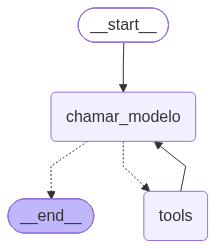

In [23]:
builder_pronto = StateGraph(EstadoFerramentas)

builder_pronto.add_node("chamar_modelo", chamar_modelo)
builder_pronto.add_node("tools", ToolNode(FERRAMENTAS_CURSO))

builder_pronto.add_edge(START, "chamar_modelo")
builder_pronto.add_conditional_edges("chamar_modelo", tools_condition)
builder_pronto.add_edge("tools", "chamar_modelo")

graph_pronto = builder_pronto.compile()

resultado = graph_pronto.invoke(
    {
        "messages": [HumanMessage("O aluno Julio já pode começar o módulo A6?")],
        "passos": 0,
    }
)

print("passos:", resultado["passos"], "| mensagens:", len(resultado["messages"]))
print(resultado["messages"][-1].text)

display_graph(graph_pronto)

## 7.1 Leitura da execução

O grafo tem a mesma forma do anterior e duas diferenças de código. A primeira é o nó de execução, que passou de uma função escrita no notebook para uma instância de `ToolNode`. A segunda é a rota, que passou a ser `tools_condition` sem mapa, porque os nomes devolvidos por ela coincidem com o nome do nó e com `END`.

O limite de passos saiu junto com a rota escrita à mão. `tools_condition` olha apenas a última mensagem, e o campo `passos` continua no estado e continua sendo contado por `chamar_modelo`, sem participar da decisão. Um limite com essa forma de rota entra como `recursion_limit` na compilação ou na chamada, ou por uma rota própria que combine as duas condições, como a da seção 6.

A pergunta desta célula pede a comparação entre o progresso do aluno e os pré-requisitos do módulo, e as duas consultas são independentes. O modelo pode emiti-las na mesma resposta ou em respostas sucessivas. A linha impressa distingue os dois casos: uma volta com dois pedidos deixa `passos` em 2 e cinco mensagens no estado, e duas voltas com um pedido cada deixam `passos` em 3 e seis mensagens. A saída gravada registra um dos dois, e outra execução pode registrar o outro.

## 7.2 Agente pronto

`create_agent` monta o grafo inteiro: o nó do modelo, o `ToolNode`, a rota entre eles e a aresta de volta. Os argumentos são o modelo, a lista de ferramentas e o prompt de sistema. O objeto devolvido é um grafo compilado, com os mesmos métodos `invoke`, `stream` e `get_graph` dos grafos montados à mão.

[0] HumanMessage
    texto: Sou a aluna Ana. Verifique meu progresso e diga o que falta para o A6.
------------------------------------------------------------
[1] AIMessage
    pedido: consultar_progresso({'nome_aluno': 'Ana'})
------------------------------------------------------------
[2] ToolMessage
    resultado: {"aluno": "Ana", "modulos": [{"modulo": "A4", "status": "em_andamento", "percentual": 70}, {"modulo": "A5", "status": "nao_iniciado", "percentual": 0}, {"modulo": "A6", "status": "nao_iniciado", "percentual": 0}]}
------------------------------------------------------------
[3] AIMessage
    pedido: consultar_cronograma({'codigo_modulo': 'A5'})
------------------------------------------------------------
[4] ToolMessage
    resultado: {"codigo": "A5", "titulo": "Grafos com chamadas de modelo", "duracao_min": 120, "pre_requisitos": ["A4"]}
------------------------------------------------------------
[5] AIMessage
    pedido: consultar_cronograma({'codigo_modulo': 'A6'})
-

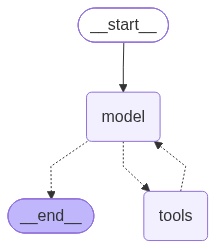

In [24]:
agente = create_agent(
    model=modelo,
    tools=FERRAMENTAS_CURSO,
    system_prompt=PROMPT_ASSISTENTE,
)

resultado = agente.invoke(
    {
        "messages": [
            HumanMessage(
                "Sou a aluna Ana. Verifique meu progresso e diga o que falta para o A6."
            )
        ]
    }
)

mostrar_conversa(resultado["messages"])

display_graph(agente)

## 7.3 Discussão

Os três arranjos executam o mesmo ciclo e diferem no que fica escrito no notebook:

| Arranjo | Escrito à mão | Ponto de extensão |
|---|---|---|
| Seção 6 | estado, dois nós, rota e mapa | qualquer um dos quatro |
| `ToolNode` e `tools_condition` | estado e nó do modelo | o nó do modelo e o estado |
| `create_agent` | nenhum | argumentos da função e middleware |

A entrada de `create_agent` dispensa o campo `passos`, porque o estado é declarado pela própria função. O grafo escrito à mão continua em uso quando o agente precisa de um campo novo no estado, de um nó de validação antes da execução, ou de uma condição de parada que combine mais de uma informação do estado, como o par pedido e contagem da seção 6.

---

# 8. Exercícios de fixação

Os exercícios modificam exemplos já executados. Use as células vazias abaixo de cada enunciado.

## Exercício 1 — Esquema de uma ferramenta

Escreva a ferramenta `resumir_modulos(codigos: list[str], campo: Literal["duracao_min", "pre_requisitos"])`, que lê `CRONOGRAMA` e devolve em JSON o valor do campo pedido para cada código recebido. Use `parse_docstring=True` e documente os dois parâmetros no bloco `Args:`. Imprima `args` e reporte como a lista e o conjunto fechado de valores aparecem no esquema. Execute a ferramenta com `invoke`, sem chamar o modelo.

## Exercício 2 — Dois pedidos na mesma mensagem

Monte à mão uma `AIMessage` com dois pedidos de `calcular_carga_total`, com argumentos e identificadores diferentes. Execute os dois, crie uma `ToolMessage` para cada um e imprima a conversa com `mostrar_conversa`. Reporte qual `tool_call_id` ficou em cada observação.

## Exercício 3 — Ferramenta de material

Escreva a ferramenta `buscar_material_complementar(codigo_modulo: str)`, que devolve em JSON dois materiais por módulo. Acrescente-a a `FERRAMENTAS_CURSO`, refaça o `bind_tools` de `modelo_assistente` e peça ao grafo `graph` os materiais complementares do A6.

## Exercício 4 — Percurso por pergunta

Execute o grafo `graph` com três perguntas: uma que nenhuma das ferramentas responde, como o número de alunos da turma; uma sobre o progresso da Ana; e a pergunta encadeada da subseção 6.2. Imprima, para cada uma, a sequência de nós devolvida por `stream_mode="updates"` e o valor final de `passos`.

## Exercício 5 — Agente com duas ferramentas

Monte com `create_agent` um agente que recebe apenas `consultar_cronograma` e `calcular_plano_estudo`. Faça a pergunta encadeada da subseção 6.2 e reporte quais ferramentas apareceram nos pedidos e quantas mensagens o histórico devolveu.

## Exercício 6 — Informação por mensagem

Sem executar código, associe cada informação abaixo à mensagem do histórico que a carrega: o nome da ferramenta escolhida, os argumentos da chamada, o resultado da consulta e o texto final ao aluno. Indique também em que ponto do ciclo cada uma aparece pela primeira vez.

---

# 9. Resumo da aula

O notebook ligou funções Python a um modelo, do caso de uma ferramenta executada à mão até um grafo que repete o ciclo de chamada e observação. Em todos os arranjos, o pedido veio do modelo e a execução ficou no código da aplicação.

| Conceito | Ideia principal |
|---|---|
| `@tool` | Converte a função em ferramenta com nome, descrição da docstring e esquema dos tipos. Com `parse_docstring=True`, o bloco `Args:` vira a descrição de cada parâmetro. |
| `description` | Texto comparado pelo modelo com o pedido do usuário na escolha da ferramenta. |
| `AIMessage.tool_calls` | Lista de pedidos de chamada, com nome, argumentos e identificador. |
| `ToolMessage` | Resultado da execução, ligado ao pedido pelo `tool_call_id`. |
| `bind_tools` | Anexa as declarações de ferramenta ao pedido enviado ao provedor. |
| Retorno em JSON | Formato do resultado lido pelo modelo e pela aplicação, com o erro como chave. |
| Laço de ferramentas | Repetição entre nó do modelo e nó de ferramentas até a resposta sem pedidos. |
| Limite de passos | Campo do estado lido pela rota, que encerra a repetição e deixa a última mensagem sem texto. |
| `ToolNode` | Nó pronto que executa os pedidos da última mensagem. |
| `tools_condition` | Rota pronta que devolve `"tools"` ou `END` conforme a última mensagem. |
| `create_agent` | Monta o grafo do agente com ferramentas a partir de modelo, lista e prompt. |

## 9.1 Checklist de compreensão

Questões de verificação:

1. Quais são os três metadados que o decorador `@tool` extrai da função?
2. O que a aplicação precisa fazer entre receber uma `AIMessage` com `tool_calls` e chamar o modelo de novo?
3. Que campo liga uma `ToolMessage` ao pedido que a originou, e por que a ordem das mensagens não basta?
4. O que `bind_tools` altera no pedido enviado ao provedor?
5. Por que uma ferramenta devolve o erro em JSON em vez de levantar uma exceção?
6. Quantas chamadas de modelo são feitas em uma pergunta que precisa de duas consultas encadeadas?
7. Que condição a rota do laço avalia além da presença de pedidos na última mensagem, e como fica a última mensagem quando essa condição encerra o laço?
8. Qual é a diferença entre o grafo da seção 6 e o grafo devolvido por `create_agent`?

## 9.2 Próximos passos

- Ferramentas com efeito externo, como escrita em banco e envio de mensagem, e a interrupção do grafo para aprovação antes da execução;
- persistência por `thread_id`, que guarda o histórico entre execuções e dispensa reenviar as mensagens à mão;
- ferramentas de busca sobre documentos, com o texto recuperado entrando na resposta como observação;
- limite de contexto no laço, quando a sequência de observações passa da janela do modelo;
- avaliação do agente por um conjunto de perguntas, medindo qual ferramenta foi chamada em cada uma.

---

# 10. Referências

- LangChain, ferramentas: https://docs.langchain.com/oss/python/langchain/tools
- LangChain, mensagens: https://docs.langchain.com/oss/python/langchain/messages
- LangChain, agentes: https://docs.langchain.com/oss/python/langchain/agents
- LangGraph, Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- Referência de API, `tool`: https://reference.langchain.com/python/langchain-core/tools/convert/tool
- Referência de API, `ToolNode`: https://reference.langchain.com/python/langgraph.prebuilt/tool_node/ToolNode
- Referência de API, `create_agent`: https://reference.langchain.com/python/langchain/agents/factory/create_agent
- Referência de API, `ChatOllama`: https://reference.langchain.com/python/langchain-ollama/chat_models/ChatOllama
- Referência de API, `ChatGoogleGenerativeAI`: https://reference.langchain.com/python/langchain-google-genai/chat_models/ChatGoogleGenerativeAI
- Ollama, documentação: https://docs.ollama.com
- Gemini, mudanças de parâmetros nos modelos recentes: https://ai.google.dev/gemini-api/docs/generate-content/latest-model#api-changes-and-parameter-updates